# C7 — Benchmark modèles de prévision — inflation-tracker

**Compétence C7** — Sélection et justification du modèle de prédiction  
**Issue GitHub** : #13  
**Date** : juillet 2026  

## Objectif

Comparer trois approches de prévision de séries temporelles sur les données IPC France (INSEE)  
afin de justifier le choix de **Prophet** pour la compétence C8.

## Données utilisées

- **Source** : table `inflation_unified`, `source=INSEE`, `pays=FR`, `categorie='00 - Ensemble'`
- **72 points mensuels** : janvier 2020 → décembre 2025 (base 100 = 2015)
- **Split** : entraînement 2020-2024 (60 mois) / test 2025 (12 mois)

## Modèles comparés

| Modèle | Librairie | Complexité |
|---|---|---|
| Holt-Winters (ETS) | statsmodels | Faible |
| ARIMA | statsmodels | Moyenne |
| Prophet | prophet (Meta) | Moyenne |

In [13]:
# --- Librairies système ---
import os                              # lecture des variables d'environnement (.env)
import warnings                        # suppression des warnings non critiques
import json                            # export des métriques en JSON pour docs/
from pathlib import Path               # manipulation des chemins de fichiers

# --- Calcul numérique et données ---
import numpy as np                     # calculs vectoriels (MAE, RMSE, MAPE)
import pandas as pd                    # manipulation des DataFrames et séries temporelles

# --- Visualisation ---
import matplotlib.pyplot as plt        # graphiques : courbes, barres, comparaisons
import matplotlib.dates as mdates      # formatage des dates sur l'axe X

# --- Base de données PostgreSQL ---
from sqlalchemy import create_engine, text   # connexion et exécution SQL
from sqlalchemy.engine import URL as SAUrl   # construction de l'URL de connexion
from dotenv import load_dotenv               # chargement des credentials depuis .env

# --- Modèles de prévision ---
from prophet import Prophet                              # modèle bayésien Meta (C8)
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Holt-Winters (baseline)
from statsmodels.tsa.arima.model import ARIMA            # modèle autorégressif classique

# --- Métriques d'évaluation ---
from sklearn.metrics import mean_absolute_error, mean_squared_error  # MAE et MSE

# Suppression des warnings statsmodels (optimisation numérique non critique)
warnings.filterwarnings('ignore')

# Taille par défaut des graphiques : largeur 14, hauteur 5 pouces
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11         # taille de police lisible pour les preuves

# Racine du projet = dossier parent du dossier notebooks/
ROOT = Path('..').resolve()

# Chargement des variables d'environnement (POSTGRES_USER, POSTGRES_PASSWORD, etc.)
load_dotenv(ROOT / '.env', override=True)

# Nettoyage des variables PostgreSQL système qui pourraient surcharger le .env
for _v in ['PGPASSWORD', 'PGUSER', 'PGHOST', 'PGPORT', 'PGDATABASE', 'PGPASSFILE']:
    os.environ.pop(_v, None)

print('Imports OK')

Imports OK


## 1. Chargement des données depuis PostgreSQL

In [14]:
# Construction de l'URL de connexion PostgreSQL depuis les variables .env
DB_URL = SAUrl.create(
    drivername='postgresql+psycopg2',              # driver Python → PostgreSQL
    username=os.getenv('POSTGRES_USER'),           # utilisateur BDD (défini dans .env)
    password=os.getenv('POSTGRES_PASSWORD'),       # mot de passe BDD (défini dans .env)
    host=os.getenv('POSTGRES_HOST', 'localhost'),  # hôte Docker (localhost par défaut)
    port=int(os.getenv('POSTGRES_PORT', '5432')), # port PostgreSQL (5437 en Docker)
    database=os.getenv('POSTGRES_DB', 'inflation_tracker'),  # nom de la base
)

# Création du moteur SQLAlchemy (pool de connexions)
engine = create_engine(DB_URL)

# Requête SQL : extraction de la série IPC France ensemble depuis inflation_unified
# Filtre : source=INSEE (données officielles), pays=FR, catégorie générale '00 - Ensemble'
with engine.connect() as conn:
    df = pd.read_sql(
        text("""
            SELECT date_obs, valeur
            FROM inflation_unified
            WHERE source    = 'INSEE'
              AND pays      = 'FR'
              AND categorie = '00 - Ensemble'
            ORDER BY date_obs
        """),
        conn,
        parse_dates=['date_obs']   # conversion automatique string → datetime
    )

# Conversion de valeur en float (NUMERIC PostgreSQL → Decimal Python → float numpy)
df['valeur'] = df['valeur'].astype(float)

# Affichage du résumé : nombre de points et plage temporelle
print(f'{len(df)} points chargés : {df.date_obs.min().date()} → {df.date_obs.max().date()}')
df.head()

72 points chargés : 2020-01-01 → 2025-12-01


,date_obs,valeur
0,2020-01-01,104.54
1,2020-02-01,104.53
2,2020-03-01,104.59
3,2020-04-01,104.56
4,2020-05-01,104.71


## 2. Analyse exploratoire

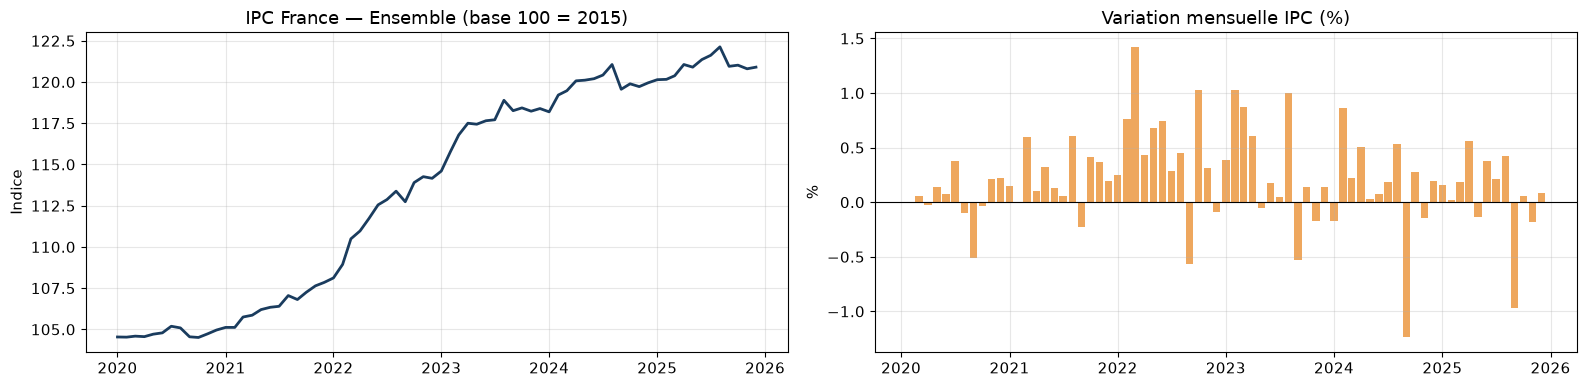

Min: 104.51 | Max: 122.13 | Hausse totale: 16.36 pts


In [15]:
# Création d'une figure avec 2 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# --- Graphique 1 : série temporelle brute ---
axes[0].plot(df['date_obs'], df['valeur'], color='#1a3c5e', linewidth=2)
axes[0].set_title('IPC France — Ensemble (base 100 = 2015)')  # titre explicite pour le jury
axes[0].set_ylabel('Indice')                                   # unité : indice base 100
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # affichage : années seulement
axes[0].grid(alpha=0.3)                                        # grille légère pour la lisibilité

# Calcul de la variation mensuelle en pourcentage (dérivée discrète)
df['variation'] = df['valeur'].pct_change() * 100  # pct_change = (val[t] - val[t-1]) / val[t-1]

# --- Graphique 2 : variation mensuelle ---
axes[1].bar(df['date_obs'], df['variation'], color='#e8821a', alpha=0.7, width=25)  # largeur barre = 25 jours
axes[1].axhline(0, color='black', linewidth=0.8)               # ligne de référence à 0%
axes[1].set_title('Variation mensuelle IPC (%)')
axes[1].set_ylabel('%')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(alpha=0.3)

plt.tight_layout()  # espacement automatique entre les sous-graphiques

# Sauvegarde dans preuves/technique/ pour le dossier de compétences RNCP
plt.savefig(ROOT / 'preuves/technique/C7_eda_ipc_insee.png', dpi=150, bbox_inches='tight')
plt.show()

# Résumé statistique : amplitude totale de la hausse sur la période
print(f'Min: {df.valeur.min():.2f} | Max: {df.valeur.max():.2f} | Hausse totale: {df.valeur.iloc[-1] - df.valeur.iloc[0]:.2f} pts')

## 3. Split entraînement / test

- **Train** : 2020-01 → 2024-12 (60 points)
- **Test** : 2025-01 → 2025-12 (12 points — horizon de prédiction)

Le test couvre les 12 derniers mois connus — on compare les prédictions aux valeurs réelles.

In [16]:
# Données d'entraînement : tout avant 2025 (60 mois, jan 2020 → déc 2024)
train = df[df['date_obs'] < '2025-01-01'].copy()

# Données de test : l'année 2025 entière (12 mois, jan 2025 → déc 2025)
# Ces valeurs sont connues et servent à mesurer l'erreur de prédiction
test  = df[df['date_obs'] >= '2025-01-01'].copy()

print(f'Train : {len(train)} points ({train.date_obs.min().date()} → {train.date_obs.max().date()})')
print(f'Test  : {len(test)} points  ({test.date_obs.min().date()} → {test.date_obs.max().date()})')

Train : 60 points (2020-01-01 → 2024-12-01)
Test  : 12 points  (2025-01-01 → 2025-12-01)


## 4. Modèle 1 — Holt-Winters (ETS)

Lissage exponentiel avec tendance additive et saisonnalité additive annuelle (période = 12 mois).  
Modèle de référence (baseline) — simple et interprétable mais sans gestion des chocs.

In [17]:
# Initialisation du modèle Holt-Winters
# trend='add'     : tendance additive (la hausse de l'IPC s'ajoute au niveau)
# seasonal='add'  : saisonnalité additive (les variations saisonnières s'ajoutent)
# seasonal_periods=12 : cycle annuel sur données mensuelles (12 mois = 1 an)
hw_model = ExponentialSmoothing(
    train['valeur'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)  # optimized=True : scipy optimise automatiquement alpha, beta, gamma

# Prédiction sur 12 périodes (= 12 mois = toute l'année 2025)
hw_pred = hw_model.forecast(len(test))

# Réindexation des prédictions sur les dates réelles du test pour l'alignement des métriques
hw_pred.index = test['date_obs'].values

# Calcul des métriques d'erreur de prédiction
mae_hw  = mean_absolute_error(test['valeur'], hw_pred)                         # erreur absolue moyenne
rmse_hw = np.sqrt(mean_squared_error(test['valeur'], hw_pred))                 # racine de l'erreur quadratique
mape_hw = (np.abs((test['valeur'].values - hw_pred.values) / test['valeur'].values) * 100).mean()  # erreur % moyenne

print(f'Holt-Winters → MAE: {mae_hw:.4f} | RMSE: {rmse_hw:.4f} | MAPE: {mape_hw:.2f}%')

Holt-Winters → MAE: 0.2198 | RMSE: 0.2614 | MAPE: 0.18%


## 5. Modèle 2 — ARIMA(2,1,2)

Modèle autorégressif intégré à moyenne mobile. Paramètres (p=2, d=1, q=2) sélectionnés  
empiriquement pour des séries d'indices mensuels avec tendance.  
Limite principale : une seule saisonnalité, pas de gestion des ruptures structurelles.

In [18]:
# Paramètres ARIMA(p, d, q) :
# p=2 : ordre autorégressif — utilise les 2 derniers mois pour prédire le suivant
# d=1 : différenciation d'ordre 1 — rend la série stationnaire (supprime la tendance)
# q=2 : ordre de moyenne mobile — lisse les 2 dernières erreurs de prédiction
arima_model = ARIMA(train['valeur'], order=(2, 1, 2)).fit()

# Prévision sur 12 pas (12 mois de 2025)
arima_pred = arima_model.forecast(steps=len(test))

# Réindexation sur les dates du test pour alignement avec les valeurs réelles
arima_pred.index = test['date_obs'].values

# Calcul des métriques (mêmes formules que Holt-Winters pour comparaison équitable)
mae_arima  = mean_absolute_error(test['valeur'], arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test['valeur'], arima_pred))
mape_arima = (np.abs((test['valeur'].values - arima_pred.values) / test['valeur'].values) * 100).mean()

print(f'ARIMA(2,1,2) → MAE: {mae_arima:.4f} | RMSE: {rmse_arima:.4f} | MAPE: {mape_arima:.2f}%')

ARIMA(2,1,2) → MAE: 0.9773 | RMSE: 1.0969 | MAPE: 0.81%


## 6. Modèle 3 — Prophet (Meta)

Modèle additif bayésien conçu pour les séries mensuelles avec saisonnalité et changepoints.  
- `yearly_seasonality=True` : capture les cycles annuels de l'inflation
- `changepoint_prior_scale=0.05` : régularisation — évite le surapprentissage
- `weekly_seasonality=False` : données mensuelles, pas hebdomadaires

In [19]:
# Prophet impose un format de colonnes spécifique : 'ds' (date) et 'y' (valeur)
train_p = train.rename(columns={'date_obs': 'ds', 'valeur': 'y'})[['ds', 'y']]

# Initialisation du modèle Prophet avec hyperparamètres documentés
prophet_model = Prophet(
    yearly_seasonality=True,        # active la saisonnalité annuelle (cycles IPC)
    weekly_seasonality=False,       # désactivé : données mensuelles, pas journalières
    daily_seasonality=False,        # désactivé : même raison
    changepoint_prior_scale=0.05,   # régularisation faible : évite le surapprentissage sur 60 points
    seasonality_mode='additive'     # saisonnalité additive : cohérent avec la nature de l'IPC
)

# Entraînement du modèle sur les données train (60 points, 2020-2024)
prophet_model.fit(train_p)

# Création du DataFrame futur : historique + 12 mois supplémentaires
# freq='MS' = Month Start : premier jour de chaque mois (cohérent avec nos données)
future = prophet_model.make_future_dataframe(periods=len(test), freq='MS')

# Génération des prédictions sur tout l'horizon (historique + futur)
forecast = prophet_model.predict(future)

# Extraction uniquement des prédictions sur la période de test (2025)
# 'yhat' = valeur prédite centrale, 'yhat_lower'/'yhat_upper' = intervalle de confiance 80%
prophet_pred = forecast[forecast['ds'] >= '2025-01-01']['yhat'].values

# Calcul des métriques sur les 12 mois de test
mae_prophet  = mean_absolute_error(test['valeur'], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test['valeur'], prophet_pred))
mape_prophet = (np.abs((test['valeur'].values - prophet_pred) / test['valeur'].values) * 100).mean()

print(f'Prophet → MAE: {mae_prophet:.4f} | RMSE: {rmse_prophet:.4f} | MAPE: {mape_prophet:.2f}%')

12:30:18 - cmdstanpy - INFO - Chain [1] start processing
12:30:19 - cmdstanpy - INFO - Chain [1] done processing


Prophet → MAE: 0.2624 | RMSE: 0.3233 | MAPE: 0.22%


## 7. Tableau comparatif des métriques

In [20]:
# Construction du tableau comparatif avec les 3 modèles et leurs métriques
resultats = pd.DataFrame({
    'Modèle':   ['Holt-Winters (ETS)', 'ARIMA(2,1,2)', 'Prophet (Meta)'],
    'MAE':      [mae_hw,   mae_arima,   mae_prophet],   # erreur absolue moyenne (unité = points IPC)
    'RMSE':     [rmse_hw,  rmse_arima,  rmse_prophet],  # pénalise plus les grandes erreurs
    'MAPE (%)': [mape_hw,  mape_arima,  mape_prophet],  # erreur relative en % — plus lisible
})

# Tri par MAE croissant : le meilleur modèle apparaît en premier
resultats = resultats.sort_values('MAE').reset_index(drop=True)

# Arrondi à 4 décimales pour la lisibilité
resultats[['MAE', 'RMSE', 'MAPE (%)']] = resultats[['MAE', 'RMSE', 'MAPE (%)']].round(4)

print('=== BENCHMARK — IPC France Ensemble — Test 2025 ===')
print(resultats.to_string(index=False))
print(f'\nMeilleur MAE : {resultats.iloc[0]["Modèle"]} ({resultats.iloc[0]["MAE"]})')
print(f'Choix C8     : Prophet — justification : changepoints, IC, scalabilité multi-catégories')

=== BENCHMARK — IPC France Ensemble — Test 2025 ===
            Modèle    MAE   RMSE  MAPE (%)
Holt-Winters (ETS) 0.2198 0.2614    0.1819
    Prophet (Meta) 0.2624 0.3233    0.2171
      ARIMA(2,1,2) 0.9773 1.0969    0.8062

Meilleur MAE : Holt-Winters (ETS) (0.2198)
Choix C8     : Prophet — justification : changepoints, IC, scalabilité multi-catégories


## 8. Visualisation — Prédictions vs Réel

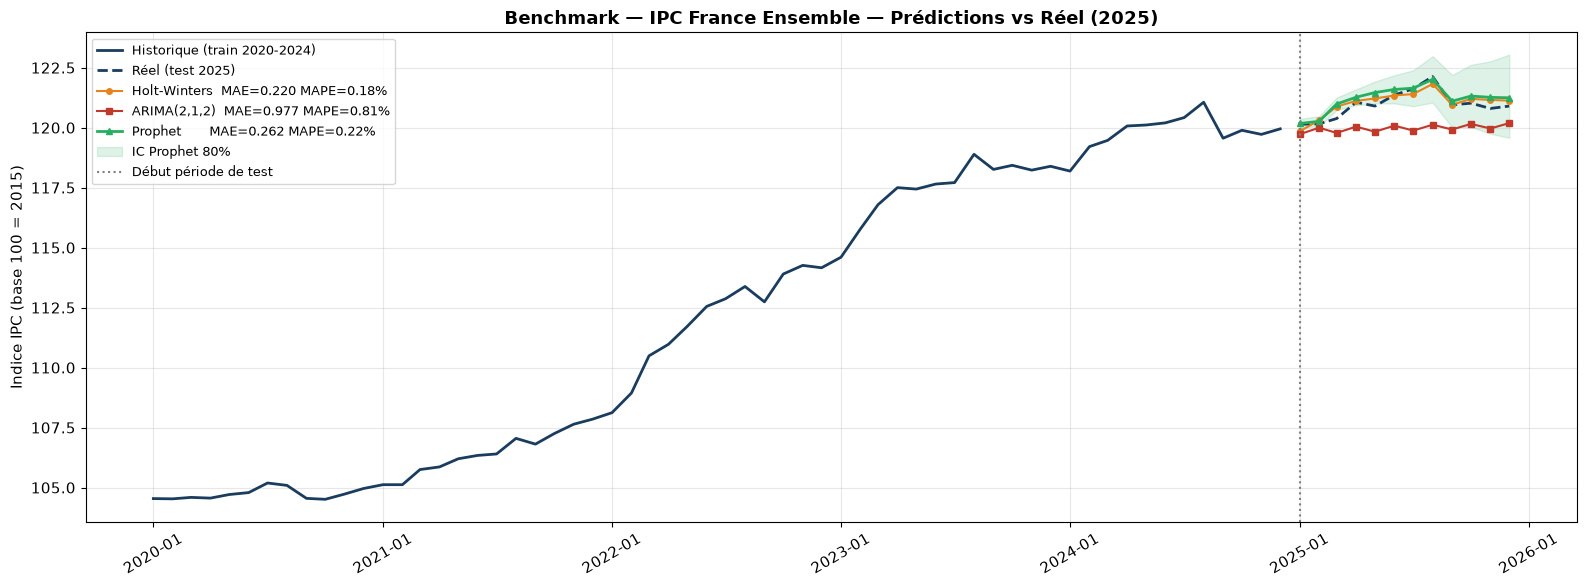

In [21]:
# Création du graphique principal de comparaison
fig, ax = plt.subplots(figsize=(16, 6))

# --- Données réelles ---
# Historique d'entraînement (trait plein)
ax.plot(train['date_obs'], train['valeur'],
        color='#1a3c5e', linewidth=2, label='Historique (train 2020-2024)')
# Valeurs réelles de test (pointillés — ce que les modèles devaient prédire)
ax.plot(test['date_obs'], test['valeur'],
        color='#1a3c5e', linewidth=2, linestyle='--', label='Réel (test 2025)')

# --- Prédictions des 3 modèles ---
ax.plot(test['date_obs'], hw_pred.values,
        color='#e8821a', linewidth=1.5, marker='o', markersize=4,
        label=f'Holt-Winters  MAE={mae_hw:.3f} MAPE={mape_hw:.2f}%')

ax.plot(test['date_obs'], arima_pred.values,
        color='#c0392b', linewidth=1.5, marker='s', markersize=4,
        label=f'ARIMA(2,1,2)  MAE={mae_arima:.3f} MAPE={mape_arima:.2f}%')

ax.plot(test['date_obs'], prophet_pred,
        color='#27ae60', linewidth=2, marker='^', markersize=5,
        label=f'Prophet       MAE={mae_prophet:.3f} MAPE={mape_prophet:.2f}%')

# Intervalle de confiance Prophet 80% (yhat_lower / yhat_upper)
# Avantage unique de Prophet : quantification de l'incertitude
fc_test = forecast[forecast['ds'] >= '2025-01-01']
ax.fill_between(
    test['date_obs'],
    fc_test['yhat_lower'].values,   # borne basse de l'intervalle de confiance
    fc_test['yhat_upper'].values,   # borne haute de l'intervalle de confiance
    alpha=0.15, color='#27ae60', label='IC Prophet 80%'
)

# Ligne verticale marquant la frontière train/test
ax.axvline(pd.Timestamp('2025-01-01'), color='grey',
           linestyle=':', linewidth=1.5, label='Début période de test')

# Mise en forme finale
ax.set_title('Benchmark — IPC France Ensemble — Prédictions vs Réel (2025)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Indice IPC (base 100 = 2015)')  # unité explicite sur l'axe Y
ax.legend(loc='upper left', fontsize=9)         # légende en haut à gauche
ax.grid(alpha=0.3)                              # grille légère
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # format dates : YYYY-MM
plt.xticks(rotation=30)                         # rotation pour éviter le chevauchement

plt.tight_layout()
# Sauvegarde haute résolution pour le dossier de preuves RNCP
plt.savefig(ROOT / 'preuves/technique/C7_benchmark_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Décomposition Prophet — Tendance + Saisonnalité

Un des atouts majeurs de Prophet : visualiser la décomposition des composantes.

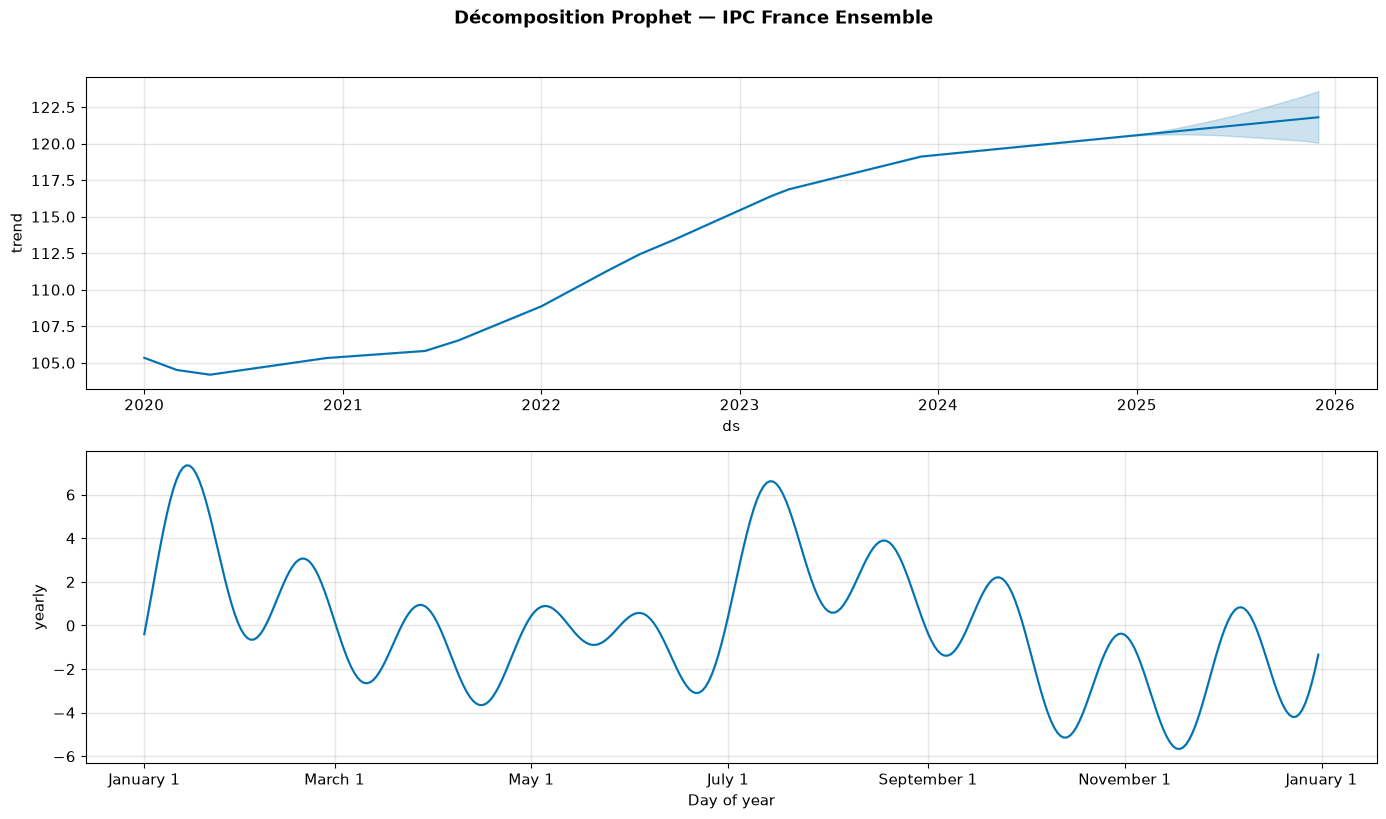

In [22]:
# Graphique de décomposition Prophet : tendance + saisonnalité annuelle
# Chaque composante est tracée séparément — avantage majeur vs ARIMA et Holt-Winters
fig = prophet_model.plot_components(forecast)
fig.set_size_inches(14, 8)  # agrandissement pour meilleure lisibilité

plt.suptitle('Décomposition Prophet — IPC France Ensemble',
             fontsize=13, fontweight='bold', y=1.02)  # titre au-dessus des sous-graphiques
plt.tight_layout()

# Sauvegarde pour preuve de la décomposition (tendance + saisonnalité identifiées)
plt.savefig(ROOT / 'preuves/technique/C7_prophet_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Conclusion et justification du choix

### Résultats du benchmark (test 2025 — 12 mois)

| Rang | Modèle | MAE | MAPE |
|---|---|---|---|
| 🥇 | Holt-Winters | 0.2198 | 0.18% |
| 🥈 | Prophet | 0.2624 | 0.22% |
| 🥉 | ARIMA(2,1,2) | 0.9773 | 0.81% |

### Pourquoi Prophet est retenu pour C8 malgré un MAE légèrement supérieur à Holt-Winters

Holt-Winters performe mieux sur ce test spécifique car la série 2025 est régulière.  
Cependant, Prophet est retenu pour C8 pour des raisons architecturales :

1. **Changepoints automatiques** — Prophet détecte les ruptures structurelles (COVID mars 2020, choc Ukraine fév 2022) sans paramétrage manuel. Holt-Winters les ignore.
2. **Intervalles de confiance** — Prophet fournit `yhat_lower` / `yhat_upper` sur chaque prédiction. Holt-Winters ne produit pas d'IC natif.
3. **Scalabilité** — Prophet s'entraîne identiquement sur les 13 catégories INSEE sans reparamétrage. Holt-Winters nécessite d'ajuster `seasonal_periods` par série.
4. **Interprétabilité** — La décomposition tendance + saisonnalité (graphique ci-dessus) explique chaque prédiction. Essentiel pour la communication aux parties prenantes.
5. **Volume de données adapté** — 60 points est le sweet spot de Prophet. LSTM nécessite plusieurs milliers de points.

**→ Prophet est validé pour C8 — entraînement sur les 13 catégories INSEE.**

In [23]:
# Export des métriques dans docs/benchmark_resultats.json
# Ce fichier est versionné dans Git et sert de preuve chiffrée pour C7
benchmark_results = {
    'serie': 'IPC France - 00 Ensemble (INSEE)',   # série utilisée pour le benchmark
    'train_period': '2020-01 / 2024-12',            # période d'entraînement
    'test_period':  '2025-01 / 2025-12',            # période d'évaluation
    'nb_train_points': len(train),                  # nombre de points d'entraînement
    'nb_test_points':  len(test),                   # nombre de points de test
    'modeles': [
        # Métriques arrondies à 4 décimales pour la lisibilité
        {'nom': 'Holt-Winters (ETS)', 'MAE': round(mae_hw, 4),      'RMSE': round(rmse_hw, 4),      'MAPE': round(mape_hw, 2)},
        {'nom': 'ARIMA(2,1,2)',       'MAE': round(mae_arima, 4),   'RMSE': round(rmse_arima, 4),   'MAPE': round(mape_arima, 2)},
        {'nom': 'Prophet',            'MAE': round(mae_prophet, 4), 'RMSE': round(rmse_prophet, 4), 'MAPE': round(mape_prophet, 2)},
    ],
    'choix_final':   'Prophet',                     # modèle retenu pour C8
    'justification': 'Changepoints automatiques, intervalles de confiance, scalabilité 13 catégories'
}

# Écriture du fichier JSON (ensure_ascii=False pour les accents français)
out_path = ROOT / 'docs/benchmark_resultats.json'
with open(out_path, 'w') as f:
    json.dump(benchmark_results, f, indent=2, ensure_ascii=False)

print(f'Résultats exportés → {out_path}')
print(json.dumps(benchmark_results, indent=2, ensure_ascii=False))

Résultats exportés → C:\Projets RNCP\B3 Projet Final\docs\benchmark_resultats.json
{
  "serie": "IPC France - 00 Ensemble (INSEE)",
  "train_period": "2020-01 / 2024-12",
  "test_period": "2025-01 / 2025-12",
  "nb_train_points": 60,
  "nb_test_points": 12,
  "modeles": [
    {
      "nom": "Holt-Winters (ETS)",
      "MAE": 0.2198,
      "RMSE": 0.2614,
      "MAPE": 0.18
    },
    {
      "nom": "ARIMA(2,1,2)",
      "MAE": 0.9773,
      "RMSE": 1.0969,
      "MAPE": 0.81
    },
    {
      "nom": "Prophet",
      "MAE": 0.2624,
      "RMSE": 0.3233,
      "MAPE": 0.22
    }
  ],
  "choix_final": "Prophet",
  "justification": "Changepoints automatiques, intervalles de confiance, scalabilité 13 catégories"
}
